In [28]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# Go To College Dataset

This dataset provides a comprehensive look at the various factors that influence a high school student’s decision to pursue college or not. It aims to shed light on the complex interplay of variables that shape a student’s educational trajectory after high school.

Kaggle: https://www.kaggle.com/datasets/saddamazyazy/go-to-college-dataset

## Data Understanding

### Packages

In [29]:
#### Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('classic')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import seaborn as sns

### Data

In [30]:
#### Fetch data
pdf = pd.read_csv('/content/drive/MyDrive/Work/PORTFOLIO/DATA ANALYTICS/Machine Learning Endeavor (College Probability)/data/go_to_college_dataset.csv')

In [31]:
#### Basic information
pdf.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   type_school            1000 non-null   object 
 1   school_accreditation   1000 non-null   object 
 2   gender                 1000 non-null   object 
 3   interest               1000 non-null   object 
 4   residence              1000 non-null   object 
 5   parent_age             1000 non-null   int64  
 6   parent_salary          1000 non-null   int64  
 7   house_area             1000 non-null   float64
 8   average_grades         1000 non-null   float64
 9   parent_was_in_college  1000 non-null   bool   
 10  will_go_to_college     1000 non-null   bool   
dtypes: bool(2), float64(2), int64(2), object(5)
memory usage: 72.4+ KB


In [32]:
#### Shape
pdf.shape

(1000, 11)

In [33]:
#### Null
pdf.isnull().sum()

,0
type_school,0
school_accreditation,0
gender,0
interest,0
residence,0
parent_age,0
parent_salary,0
house_area,0
average_grades,0
parent_was_in_college,0


In [34]:
### Duplicate
pdf.duplicated().sum()

np.int64(0)

In [35]:
#### First 5 rows
pdf.head()

,type_school,school_accreditation,gender,interest,residence,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college
0,Academic,A,Male,Less Interested,Urban,56,6950000,83.0,84.09,False,True
1,Academic,A,Male,Less Interested,Urban,57,4410000,76.8,86.91,False,True
2,Academic,B,Female,Very Interested,Urban,50,6500000,80.6,87.43,False,True
3,Vocational,B,Male,Very Interested,Rural,49,6600000,78.2,82.12,True,True
4,Academic,A,Female,Very Interested,Urban,57,5250000,75.1,86.79,False,False


In [36]:
### Describe Numerical Variables
pdf.describe()

,parent_age,parent_salary,house_area,average_grades
count,1000.000000,1.000000e+03,1000.000000,1000.000000
mean,52.208000,5.381570e+06,74.515300,86.097200
std,3.500427,1.397546e+06,15.293346,3.378738
min,40.000000,1.000000e+06,20.000000,75.000000
25%,50.000000,4.360000e+06,64.600000,83.737500
50%,52.000000,5.440000e+06,75.500000,85.575000
75%,54.000000,6.382500e+06,84.825000,88.262500
max,65.000000,1.000000e+07,120.000000,98.000000


## EDA

Target: As the purpose of this endeavor is to know what is the deciding factor for students in deciding to pursue college, the variable "will_go_to_college" is the target and must be taken note of.

###Numerical

In [37]:
### Correlation
pdf.corr(numeric_only=True)

,parent_age,parent_salary,house_area,average_grades,parent_was_in_college,will_go_to_college
parent_age,1.000000,-0.286418,0.107060,-0.006077,-0.438322,0.042873
parent_salary,-0.286418,1.000000,0.138357,0.306712,0.106487,0.475693
house_area,0.107060,0.138357,1.000000,0.409565,0.145186,0.467267
average_grades,-0.006077,0.306712,0.409565,1.000000,0.236713,0.505133
parent_was_in_college,-0.438322,0.106487,0.145186,0.236713,1.000000,0.048038
will_go_to_college,0.042873,0.475693,0.467267,0.505133,0.048038,1.000000


Based on the result of the correlation we can take note the variables house_area, parent_salary and average_grades, these variables have a "good" correlation " with our target "will_go_to_college"

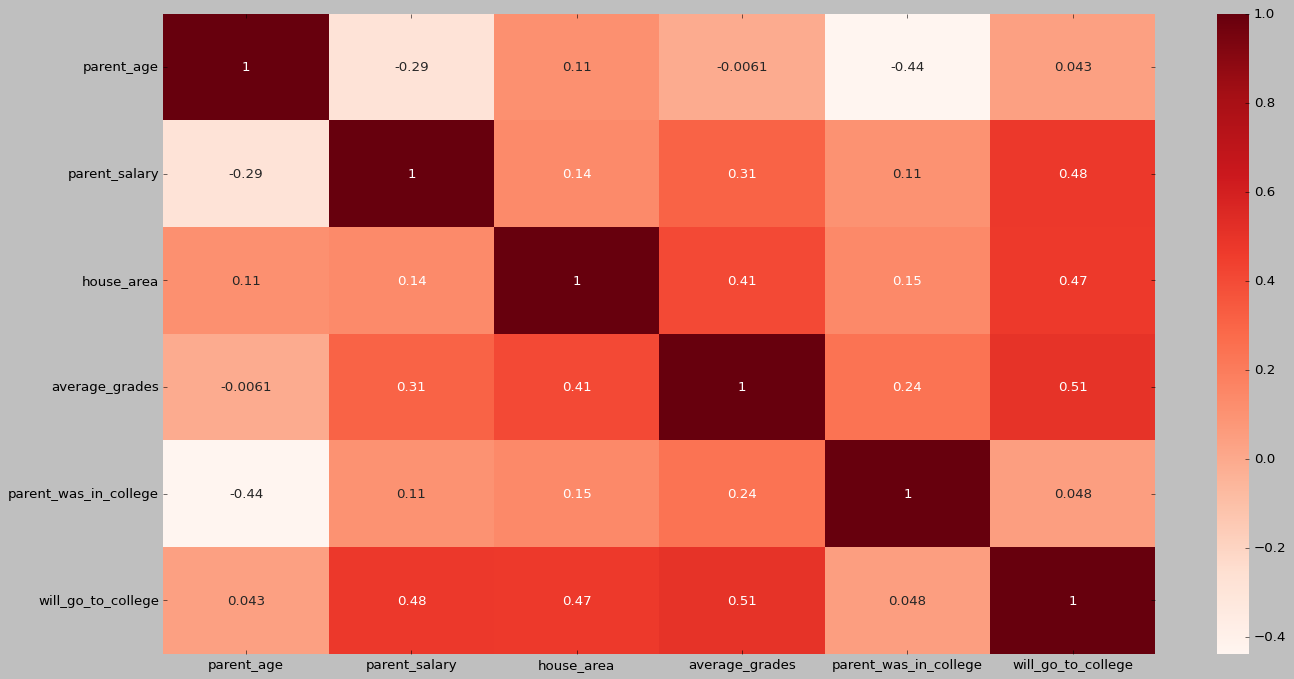

In [38]:
### Correlation Heatmap
plt.figure(figsize=(20,10))
sns.heatmap(pdf.corr(numeric_only=True),annot=True,cbar=True,cmap='Reds')
plt.show()


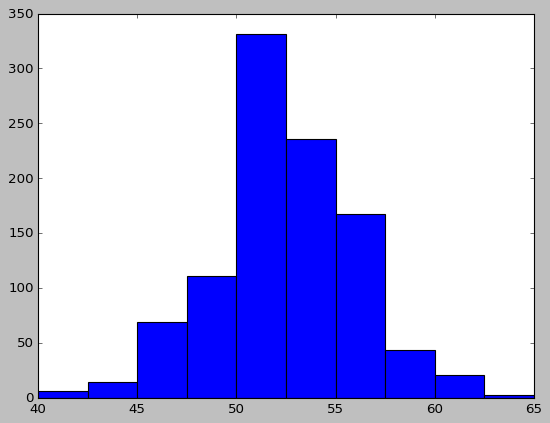

In [39]:
### Parent Age
plt.hist(x='parent_age', data=pdf, bins=10,);
plt.show()

<Axes: xlabel='will_go_to_college', ylabel='parent_age'>

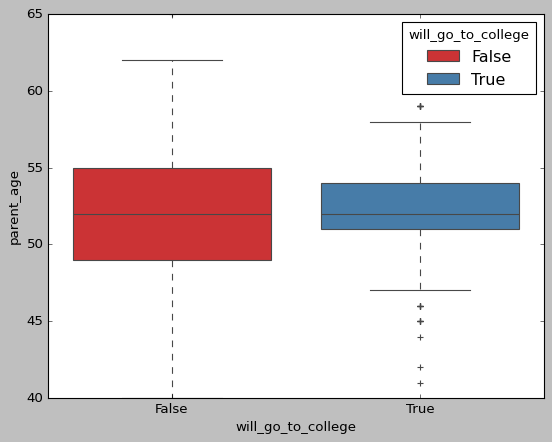

In [40]:
sns.boxplot(x = "will_go_to_college", y = "parent_age", hue = "will_go_to_college", palette = "Set1", data = pdf)


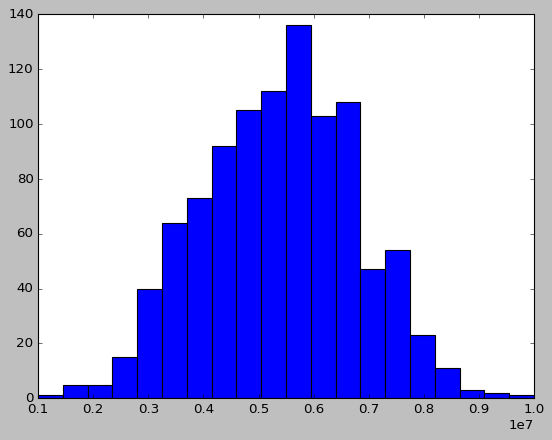

In [41]:
### Parent Salary
plt.hist(x='parent_salary', data=pdf, bins=20);
plt.show()

<Axes: xlabel='will_go_to_college', ylabel='parent_salary'>

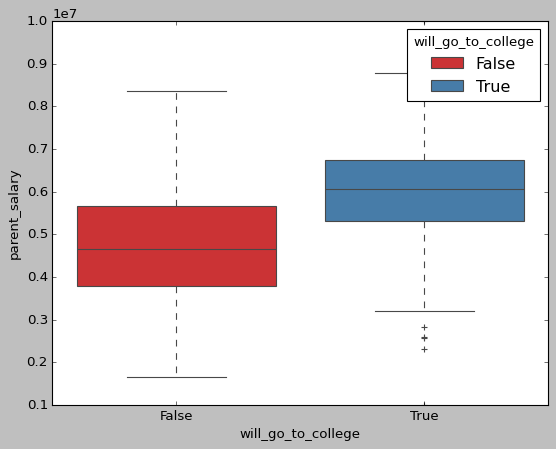

In [42]:
sns.boxplot(x = "will_go_to_college", y = "parent_salary", hue = "will_go_to_college", palette = "Set1", data = pdf)


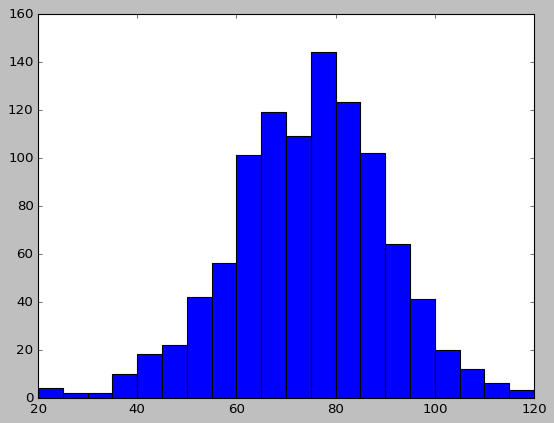

In [43]:
### House Area
plt.hist(x='house_area', data=pdf, bins=20);
plt.show()

<Axes: xlabel='will_go_to_college', ylabel='house_area'>

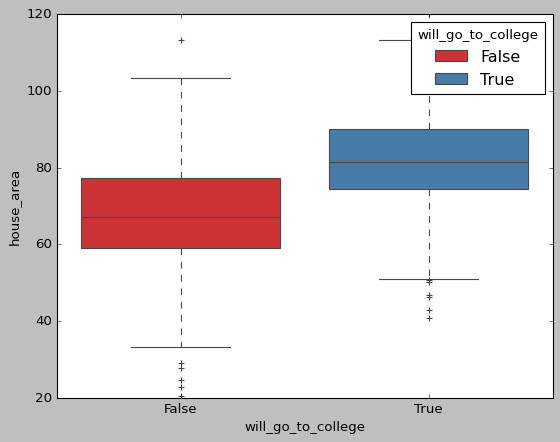

In [44]:
sns.boxplot(x = "will_go_to_college", y = "house_area", hue = "will_go_to_college", palette = "Set1", data = pdf)


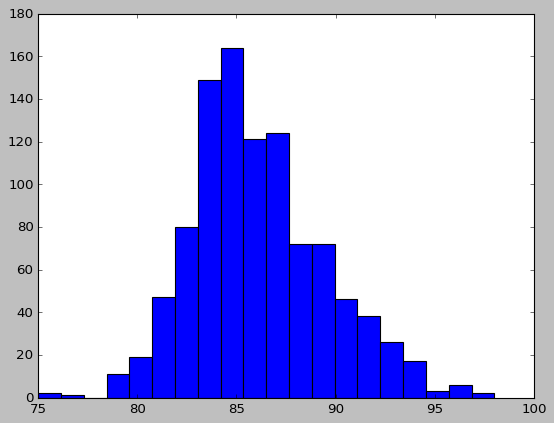

In [45]:
### Average Grades
plt.hist(x='average_grades', data=pdf, bins=20);
plt.show()

<Axes: xlabel='will_go_to_college', ylabel='average_grades'>

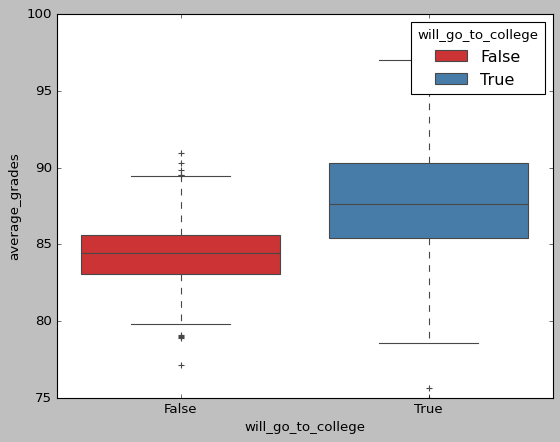

In [46]:
sns.boxplot(x = "will_go_to_college", y = "average_grades", hue = "will_go_to_college", palette = "Set1", data = pdf)


###Categorical

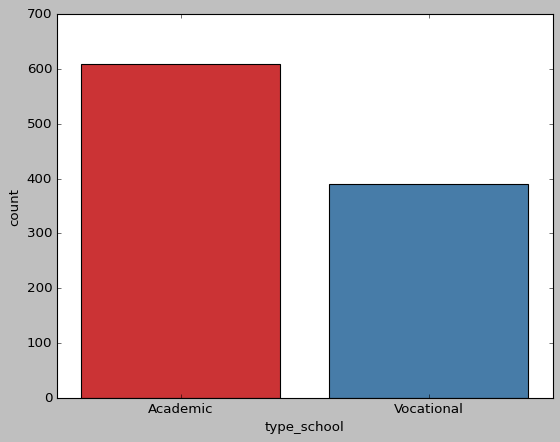

In [47]:
### School Type
sns.countplot(x='type_school', hue='type_school', palette='Set1', data=pdf)
plt.show()

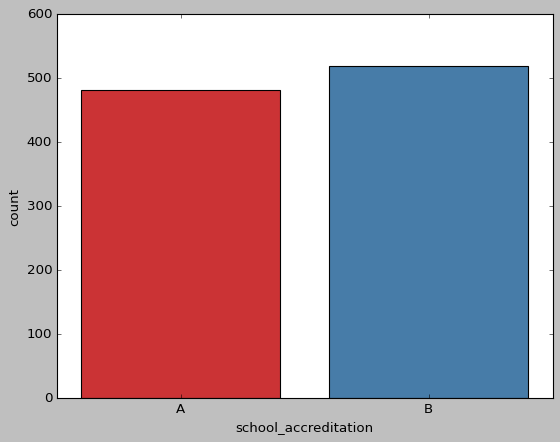

In [48]:
### School Accreditation
sns.countplot(x='school_accreditation', hue='school_accreditation', palette='Set1', data=pdf)
plt.show()

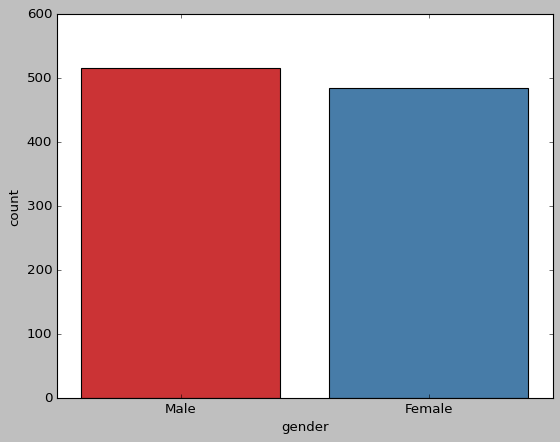

In [49]:
### Gender
sns.countplot(x='gender', hue='gender', palette='Set1', data=pdf)
plt.show()

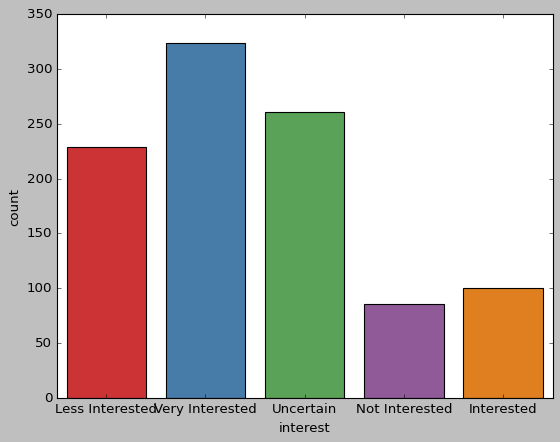

In [50]:
### Interest
sns.countplot(x='interest', hue='interest', palette='Set1', data=pdf)
plt.show()

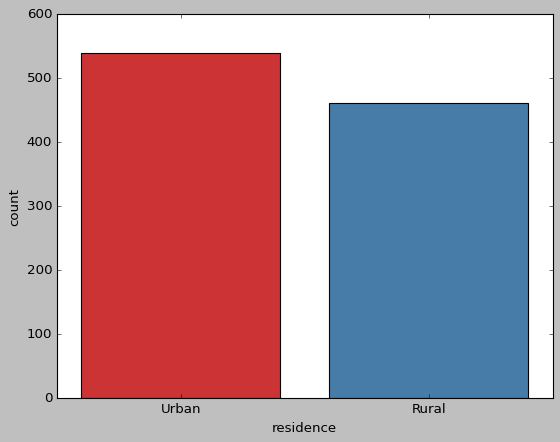

In [51]:
### Residence
sns.countplot(x='residence', hue='residence', palette='Set1', data=pdf)
plt.show()

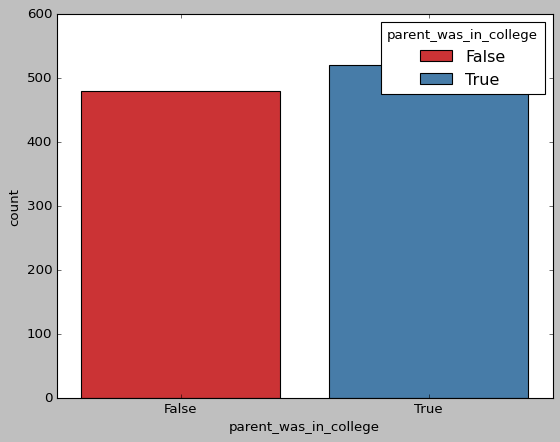

In [52]:
### Has parent attended college?
sns.countplot(x='parent_was_in_college', hue='parent_was_in_college', palette='Set1', data=pdf)
plt.show()

<Axes: xlabel='will_go_to_college', ylabel='count'>

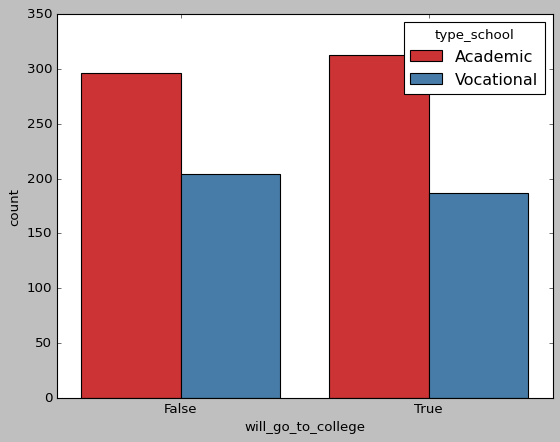

In [53]:
sns.countplot(x = 'will_go_to_college', hue= 'type_school', palette='Set1', data = pdf)

<Axes: xlabel='will_go_to_college', ylabel='count'>

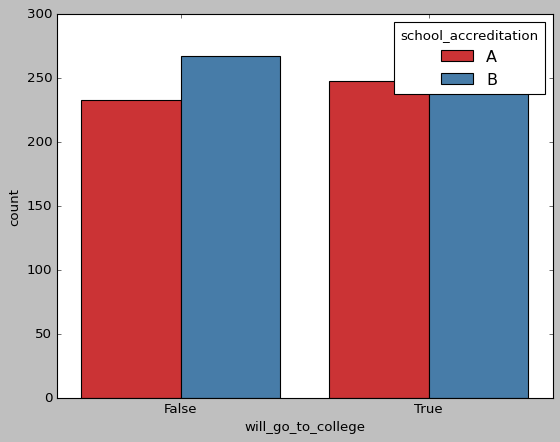

In [54]:
sns.countplot(x = 'will_go_to_college', hue= 'school_accreditation', palette='Set1', data = pdf)

<Axes: xlabel='will_go_to_college', ylabel='count'>

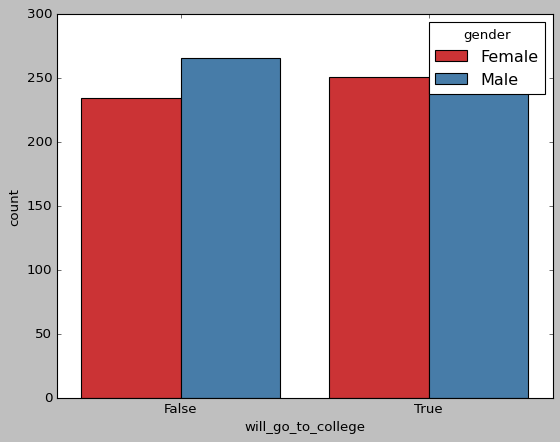

In [55]:
sns.countplot(x = 'will_go_to_college', hue= 'gender', palette='Set1', data = pdf)

<Axes: xlabel='interest', ylabel='count'>

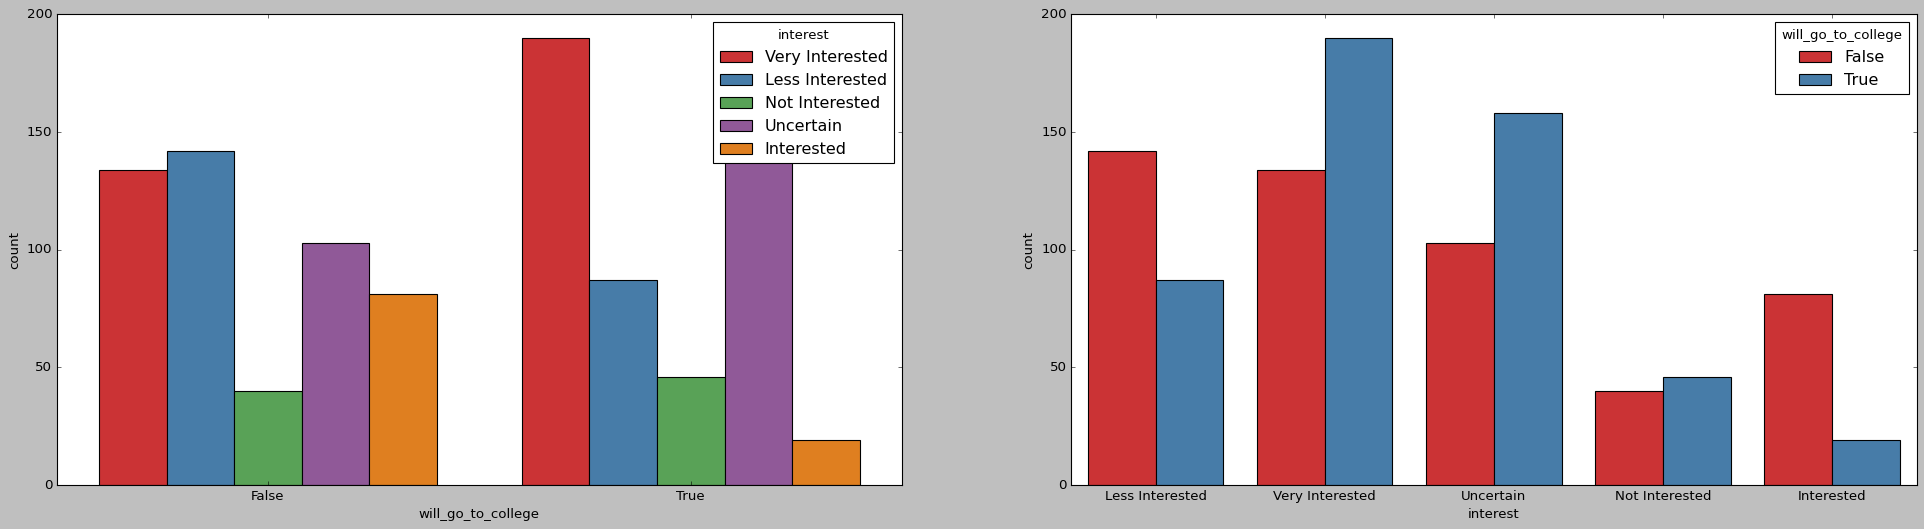

In [56]:
plt.figure(figsize = (30,25))
plt.subplot(3,2,1)
sns.countplot(x = 'will_go_to_college', hue= 'interest', palette='Set1', data = pdf)

plt.subplot(3,2,2)
sns.countplot(x='interest', hue='will_go_to_college', palette='Set1', data=pdf)

<Axes: xlabel='will_go_to_college', ylabel='count'>

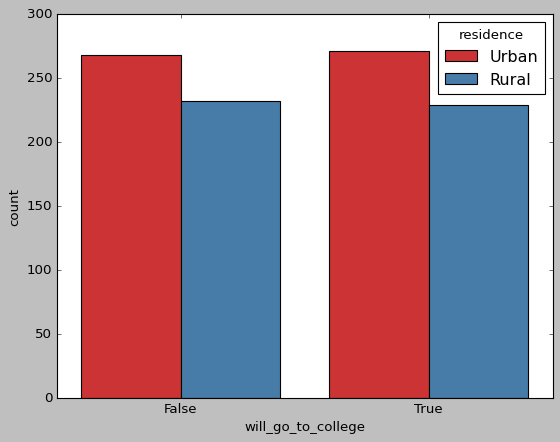

In [57]:
sns.countplot(x = 'will_go_to_college', hue= 'residence', palette='Set1', data = pdf)

<Axes: xlabel='will_go_to_college', ylabel='count'>

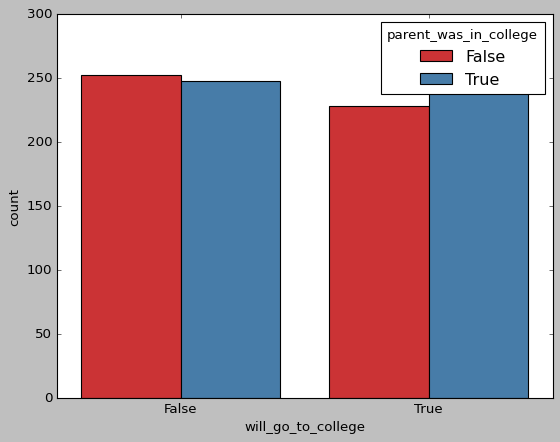

In [58]:
sns.countplot(x = 'will_go_to_college', hue= 'parent_was_in_college', palette='Set1', data = pdf)

###Model

In [59]:
data = pdf.copy()

In [60]:
# Separate target variable and features
y = data['will_go_to_college']
X = data.drop(['will_go_to_college'], axis=1)

In [61]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# Model
estimator = LogisticRegression()

# Create transformers for categorical and numeric features
preprocessor = ColumnTransformer(
    transformers=[
        ('cat_onehot', OneHotEncoder(handle_unknown='ignore'), ['type_school', 'school_accreditation', 'gender', 'interest', 'residence', 'parent_was_in_college' ])
        #,('num_standard', StandardScaler(), [''])
        ,('num_minmax', MinMaxScaler(), ['average_grades', 'parent_salary', 'house_area', 'parent_age'])
    ],
    remainder='passthrough',
)

# Create a logistic regression model using a pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
    ,('estimator', estimator)
])

# Fit training data into model pipeline
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_onehot',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type_school',
                                                   'school_accreditation',
                                                   'gender', 'interest',
                                                   'residence',
                                                   'parent_was_in_college']),
                                                 ('num_minmax', MinMaxScaler(),
                                                  ['average_grades',
                                                   'parent_salary',
                                                   'house_area',
                                                   'parent_age'])])),
                ('estimator', LogisticRegression())])

Accuracy: 0.86
Precision: 0.85
Recall: 0.87

Confusion Matrix:
[[332  62]
 [ 53 353]]


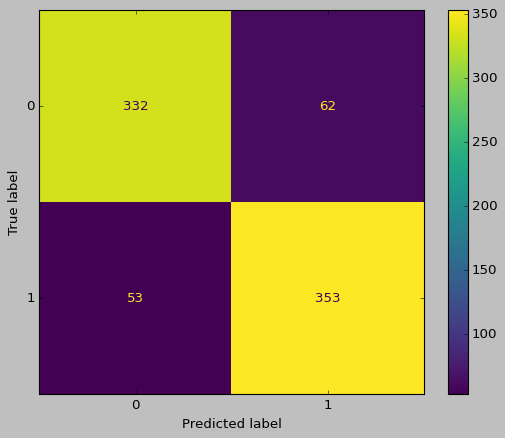

In [63]:
# Make predictions on the train set
y_pred_train = pipeline.predict(X_train)

# Evaluate the model
accuracy_train = accuracy_score(y_train, y_pred_train)
precision_train = precision_score(y_train, y_pred_train)
recall_train = recall_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)

print(f"Accuracy: {accuracy_train:.2f}")
print(f"Precision: {precision_train:.2f}")
print(f"Recall: {recall_train:.2f}")
print(f"\nConfusion Matrix:")
print(cm_train)

cmd_train = ConfusionMatrixDisplay(cm_train)
cmd_train.plot()

Accuracy: 0.85
Precision: 0.81
Recall: 0.90

Confusion Matrix:
[[86 20]
 [ 9 85]]


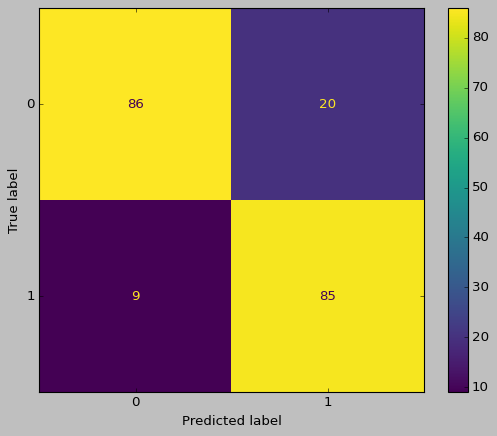

In [64]:
# Make predictions on the test set
y_pred_test = pipeline.predict(X_test)

# Evaluate the model
accuracy_test = accuracy_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
recall_test = recall_score(y_test, y_pred_test)
cm_test = confusion_matrix(y_test, y_pred_test)

print(f"Accuracy: {accuracy_test:.2f}")
print(f"Precision: {precision_test:.2f}")
print(f"Recall: {recall_test:.2f}")
print(f"\nConfusion Matrix:")
print(cm_test)

cmd_test = ConfusionMatrixDisplay(cm_test)
cmd_test.plot()

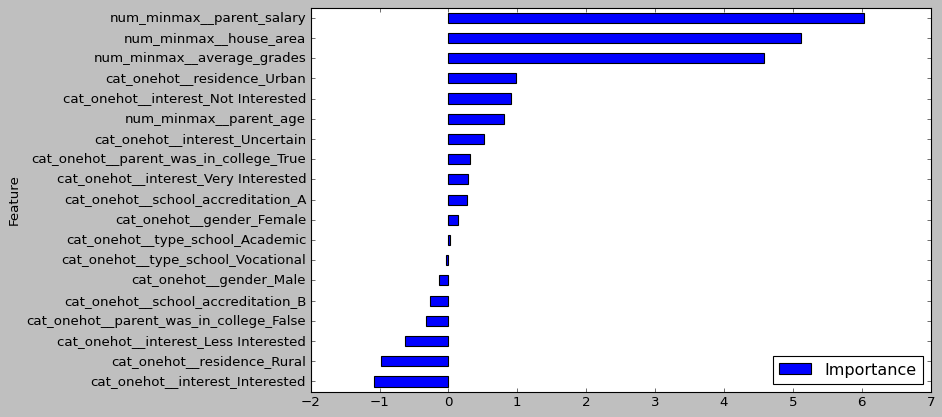

Intercept: -8.259981447600092


In [65]:
#### Get coefficients & intercept

coefficients = pipeline.named_steps.estimator.coef_[0]
feature_names = pipeline.named_steps.preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': coefficients})
feature_importance = feature_importance.sort_values('Importance', ascending=True)
feature_importance.plot(x='Feature', y='Importance', kind='barh', figsize=(10, 6))
plt.show()

intercept = pipeline.named_steps.estimator.intercept_[0]
print(f'Intercept: {intercept}')